# 05 Rating Prediction

Predict the customer rating an invoice will receive (target `Rating`, scale 4 to 10) from transaction context. The use case is twofold: spot drivers of low ratings, and let the dashboard expose a what if predictor.

Two models are trained on the same train test split (80 / 20, seed 42):

| Model | Role | Why |
|-------|------|-----|
| `Ridge` | Linear baseline | Tells us whether anything beats a simple regularised linear fit. If a tree does not, the signal is weak and we should not over claim. |
| `GradientBoostingRegressor` | Non linear contender | Captures interactions (for example branch by product line by hour) that a linear model misses. |

Both models share a `ColumnTransformer` preprocessor: `StandardScaler` on the seven numeric columns, `OneHotEncoder(handle_unknown=ignore)` on the three categorical columns. Wrapping preprocessor and estimator in a `Pipeline` means the saved `rating_model.joblib` accepts the same raw schema the dashboard form produces, no double serialisation needed.

Reported metrics: MAE and RMSE in rating points. The winner (lower MAE) is also the model passed to SHAP for explanation.

SHAP global beeswarm plot answers which features push rating up or down across the population. The dashboard uses local SHAP per prediction to answer why this score for this customer.

In [1]:
import os, warnings
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')
os.environ.setdefault('TQDM_DISABLE', '1')
warnings.filterwarnings('ignore')
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.viz import set_style, fmt_money

set_style()
RNG = np.random.default_rng(config.RANDOM_SEED)


In [2]:
from src.data_loader import load_processed
from src.modelling import regression_metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import joblib

df = load_processed()


## Feature matrix


In [3]:
num = ['Unit price', 'Quantity', 'Total', 'Hour', 'IsWeekend', 'IsMember', 'IsFemale']
cat = ['Branch', 'Product line', 'Payment']
X = df[num + cat]
y = df['Rating']

pre = ColumnTransformer([
    ('num', StandardScaler(), num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat),
])


## Train and score


In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=config.RANDOM_SEED)

ridge = Pipeline([('pre', pre), ('m', Ridge(alpha=1.0, random_state=config.RANDOM_SEED))]).fit(X_tr, y_tr)
gbr = Pipeline([('pre', pre), ('m', GradientBoostingRegressor(random_state=config.RANDOM_SEED))]).fit(X_tr, y_tr)

ridge_metrics = regression_metrics(y_te, ridge.predict(X_te))
gbr_metrics = regression_metrics(y_te, gbr.predict(X_te))
metrics_tbl = pd.DataFrame({'ridge': ridge_metrics, 'gbr': gbr_metrics}).T
metrics_tbl


,mae,rmse
ridge,1.415017,1.664240
gbr,1.437730,1.720816


## SHAP explanations
SHAP picks TreeExplainer for the gradient boosting model and LinearExplainer for the ridge baseline. We pass a transformed background sample so SHAP can model feature dependencies.


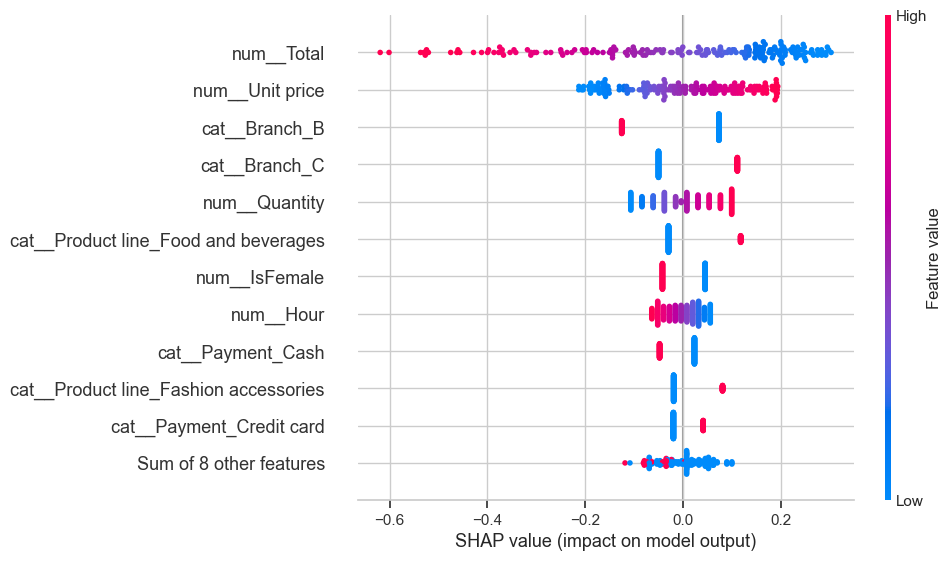

In [5]:
import shap

best = gbr if gbr_metrics['mae'] <= ridge_metrics['mae'] else ridge
X_te_t = best.named_steps['pre'].transform(X_te)
X_te_arr = X_te_t.toarray() if hasattr(X_te_t, 'toarray') else X_te_t
feature_names = list(best.named_steps['pre'].get_feature_names_out())

try:
    explainer = shap.Explainer(best.named_steps['m'], X_te_arr)
except Exception:
    explainer = shap.Explainer(best.named_steps['m'].predict, X_te_arr)

shap_values = explainer(X_te_arr)
if hasattr(shap_values, 'feature_names'):
    shap_values.feature_names = feature_names
shap.plots.beeswarm(shap_values, max_display=12, show=True)


## Persist artifacts


In [6]:
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best, config.RATING_MODEL)
metrics_tbl.to_parquet(config.RATING_METRICS_PARQUET)

shap_df = pd.DataFrame(shap_values.values, columns=feature_names)
shap_df.to_parquet(config.RATING_SHAP_PARQUET, index=False)
print('saved rating model, metrics, shap values')


saved rating model, metrics, shap values
